# The Stabilizer formalism

### Pauli operations and observables

In [163]:
import numpy as np
from qiskit import QuantumCircuit, transpile, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from qiskit.circuit.library import PauliGate
from qiskit.quantum_info import Statevector

X


'Statevector : '

<IPython.core.display.Latex object>

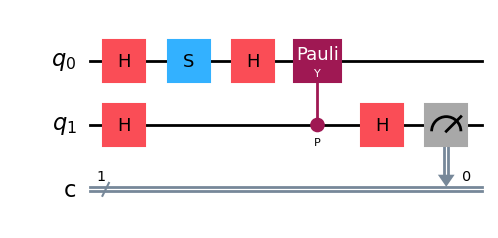

In [110]:
# random choose pauli matrices
index = np.random.randint(0,3)
PauliChoice = ["X","Y","Z"]
print(PauliChoice[0])

qc = QuantumCircuit(2,1)
pauliGate = PauliGate(PauliChoice[1]).control(label="P")

qc.h(0)
qc.s(0)
qc.h(0)
qc.h(1)

display("Statevector : ", Statevector.from_instruction(qc).draw("latex"))

qc.append(pauliGate, [1,0])
qc.h(1)
qc.measure(1,0)
qc.draw("mpl")

Pauli gate :  X


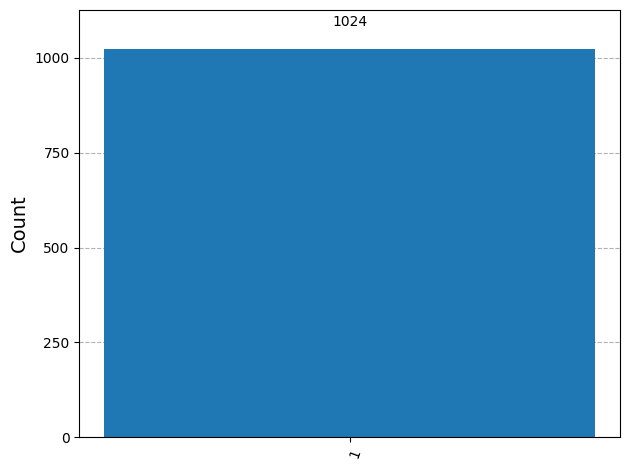

In [109]:
sim = AerSimulator()
result = sim.run(transpile(qc.decompose(gates_to_decompose="cpauli"))).result()
count = result.get_counts()
print("Pauli gate : ", PauliChoice[index])
plot_histogram(count)

P :  ['Z', 'Y', 'Z']


'Statevector : '

<IPython.core.display.Latex object>

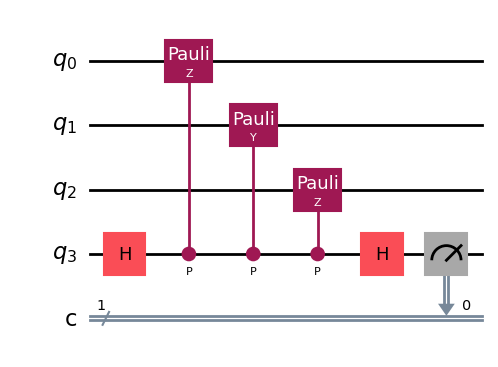

In [150]:
# for 3 qubit pauli operation
# random choose pauli matrices
index = np.random.randint(0,3, size=3)
PauliChoice = ["X","Y","Z"]

qc = QuantumCircuit(4,1)
qc.h(3)
P = []
for i in range(0,len(index)):
    P.append(PauliChoice[index[i]])
    pauliGate = PauliGate(PauliChoice[index[i]]).control(label="P")
    qc.append(pauliGate, [3,i])

print("P : ", P)
display("Statevector : ", Statevector.from_instruction(qc).draw("latex"))

qc.h(3)
qc.measure(3,0)
qc.draw("mpl")


Pauli gate :  ['Z', 'Y', 'Z']


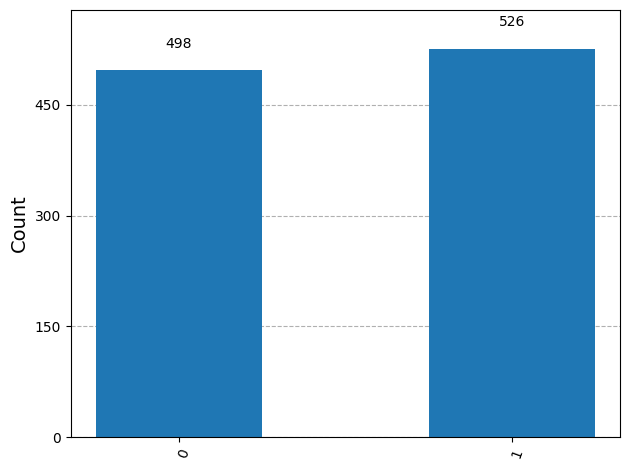

In [151]:
sim = AerSimulator()
result = sim.run(transpile(qc.decompose(gates_to_decompose="cpauli"))).result()
count = result.get_counts()
print("Pauli gate : ", P)
plot_histogram(count)

### Repetition code revisited
#### Pauli observable for the repetition code

'statevector : '

<IPython.core.display.Latex object>

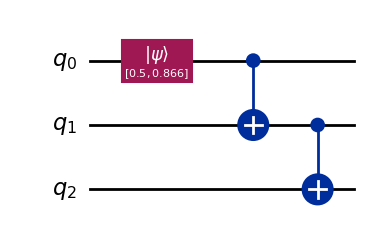

In [197]:
sv = Statevector([1/2, np.sqrt(3)/2])
circuit = QuantumCircuit(3)
circuit.initialize(sv, 0)
circuit.cx(range(0,2), range(1,3))
display("statevector : ", Statevector.from_instruction(circuit).draw("latex"))
circuit.draw("mpl")

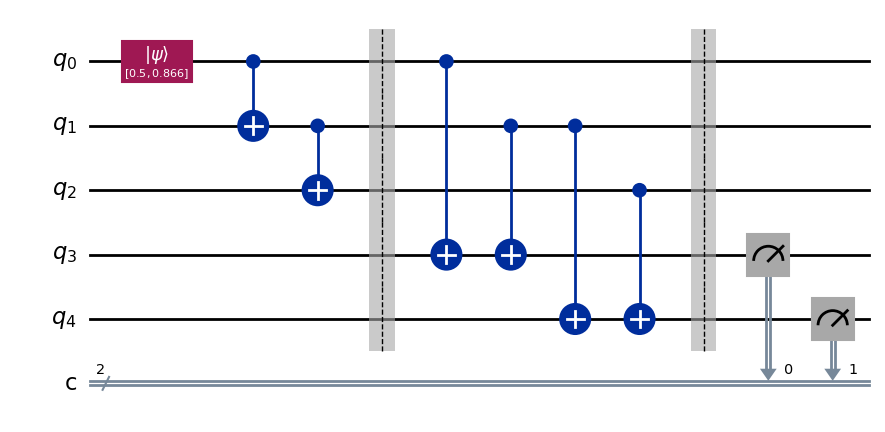

In [198]:
measr = QuantumRegister(2, "meas")
cr = ClassicalRegister(2, "cr")
qc = QuantumCircuit(measr, cr)

circuitTot = QuantumCircuit(5, 2)
circuitTot.compose(circuit, range(0,3), inplace=True)
circuitTot.compose(qc, range(3,5), range(0,2), inplace=True)
circuitTot.barrier()

circuitTot.cx(0,3)
circuitTot.cx(1,3)
circuitTot.cx(1,4)
circuitTot.cx(2,4)
circuitTot.barrier()

circuitTot.measure([3,4], [0,1])
circuitTot.draw("mpl")

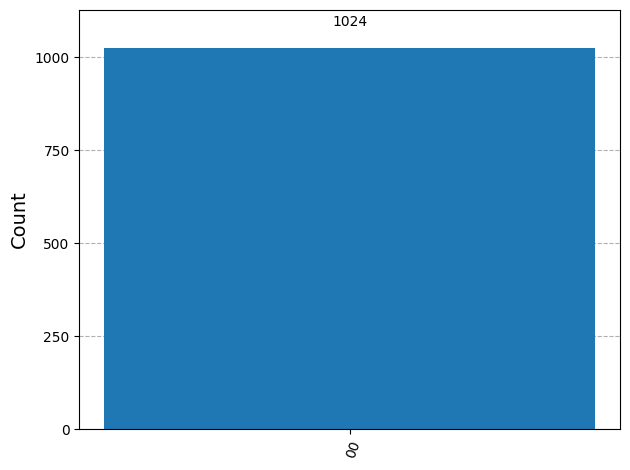

In [199]:
sim = AerSimulator()
result = sim.run(transpile(circuitTot)).result()
count = result.get_counts()
plot_histogram(count)